# AureaMind Exploratory Data Analisis

The followin is an organic project that follows the whole end-to-end Data Proyect for AureaMind. 
In the previous step and notebook "df_generator" you can find the functions that created the 6 syntetic DataSets for this proyect.

At the beggening, this EDA was made step by step in a very exploratory way, by the time the first DF EDA was finished, a series of functions came to mind. 

The first function creates written EDA
The next two fucntions ilustrate better each variable and save the figures into the dat folders for future repositories, reports and exploration.

In [2]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlip.pyplot as plt
import os
os.chdir('C:/Users/vorte/Documents/AureaMind/data/raw')

In [4]:
# Creating a fuction that give us instant EDA for the DataFrame.

def generate_EDA(df_name):    # most be str
    if not isinstance(df_name, str):
        raise TypeError('df name most be a str (the CSV File name)')
    dataframe = pd.read_csv(df_name)
    print(f'============== Data frame {df_name} INSTANT EDA =========================\n\n')
    print(f"There are {len(dataframe)} Observations")
    print(f"There are {dataframe.shape[1]} columns ")
    print(f'there are {dataframe.describe().shape[1]} numeric variables and {(dataframe.shape[1]) - (dataframe.describe().shape[1])} categorical variables, of the {dataframe.shape[1]} total columns\n')

    dataframe_numeric_columns = dataframe.select_dtypes(include= 'number').columns
    dataframe_categorical_columns = dataframe.select_dtypes(exclude='number').columns
    print(f'Numerical Columns:\n + {dataframe_numeric_columns}\n')
    print(f'Categorical Columns: \n {dataframe_categorical_columns}\n\n')

    print( '============== Numeric variables info =========================\n')
    print(f'{dataframe.describe()}\n\n')
    print( '============== Categorical variables info =========================\n') 
    for variable in dataframe_categorical_columns:
        print(f"{dataframe.groupby(f'{variable}').size()}\n")
    print(f"===================== {df_name.upper()}'S INSTANT EDA FINISHED ====================\n\n")
    return dataframe.head()
    

In [106]:
# Creando una funcion que grafique cada variable categorica para apreciarlo mejor visualmente
import matplotlib.pyplot as plt

def plot_categorical(df_name):
    df = pd.read_csv(df_name)
    categorical_columns = df.select_dtypes(exclude = 'number').columns
    
    for column in categorical_columns:
        column_name = column.lower().replace(" ", "_")
        # organizing the axes X y Y:
        column_values  = df[column].value_counts()
        # Background
        plt.figure(facecolor = 'beige')
        plt.gca().set_facecolor('beige')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        # figure:
        plt.bar(column_values.index,column_values.values, color='#E07A7A')
        plt.title(f"{column_name} distribution", fontsize = 16, fontname = 'Georgia', loc='left', pad=15)
        plt.xlabel(column )
        plt.ylabel('N° Users')
        plt.yticks(fontsize = 8)
        plt.xticks(fontsize = 8)
        plt.grid(axis = 'y', linestyle = '--', alpha= 0.6)

        # Saving fig for reports
        filename = f"{column_name}_distribution.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
    

In [134]:
# Creating a function to plot ever numeric variable so its presentable.
def plot_numeric(df_name):
    df = pd.read_csv(df_name)
    numeric_columns = df.select_dtypes(include ='number').drop(columns = ['user_id'], errors='ignore')
    numeric_columns = numeric_columns.columns
    
    for column in numeric_columns:

        # stats values:
        data = df[column].dropna()
        mean_val = data.mean()
        median_val = data.median()
        min_val = data.min()
        max_val = data.max()
        
        plt.figure(facecolor = 'beige')
        plt.gca().set_facecolor('beige')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

        plt.hist(data, bins=20, color='#E07A7A', edgecolor='white', alpha=0.85)

        # stats-lines
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=1,
                    label=f'Mean: {mean_val:.2f}')
        plt.axvline(median_val, color='orange', linestyle=':', linewidth=1.5,
                    label=f'Median: {median_val:.2f}')
        plt.axvline(min_val, color='orangered', linestyle='-', linewidth=1,
                    label=f'Min: {min_val:.2f}')
        plt.axvline(max_val, color='orangered', linestyle='-', linewidth=1,
                    label=f'Max: {max_val:.2f}')
        
        plt.title(f'{column} distribution', fontsize = 14, fontname = "Georgia", loc = 'left', pad = 15)
        plt.xlabel(column)
        plt.ylabel('N° Users')
        plt.yticks(fontsize = 8)
        plt.xticks(fontsize = 8)
        plt.grid(axis = 'y', linestyle = '--', alpha= 0.6)
        plt.legend(frameon=False, fontsize=8)

        # saving fig
        plt.savefig(f'{column}_distribution.png', dpi= 300, bbox_inches = 'tight')
        plt.show()
    

In [66]:
generate_EDA('users.csv')

============== Data frame users.csv INSTANT EDA =========================


There are 1000 Observations
There are 14 columns 
there are 5 numeric variables and 9 categorical variables, of the 14 total columns

Numerical Columns:
 + Index(['user_id', 'age', 'baseline_stress', 'baseline_anxiety',
       'baseline_depression'],
      dtype='object')

Categorical Columns: 
 Index(['country', 'education_level', 'employment_status',
       'relationship_status', 'has_children', 'signup_date', 'program_type',
       'dropout', 'dropout_date'],
      dtype='object')


============== Numeric variables info =========================

           user_id         age  baseline_stress  baseline_anxiety  \
count  1000.000000  1000.00000      1000.000000       1000.000000   
mean    500.500000    38.82800         5.501000          5.440000   
std     288.819436    12.16439         2.071301          2.007095   
min       1.000000    18.00000         2.000000          2.000000   
25%     250.750000    2

,user_id,age,country,education_level,employment_status,relationship_status,has_children,baseline_stress,baseline_anxiety,baseline_depression,signup_date,program_type,dropout,dropout_date
0,1,30,Colombia,High School,Student,Single,False,5.0,5.0,6.0,2025-10-20,Therapy,True,2025-12-31
1,2,32,Colombia,Bachelor,Freelancer,Married,False,3.0,7.0,4.0,2025-10-07,Therapy,False,2025-12-31
2,3,40,Argentina,PhD,Employed,In Relationship,True,4.0,5.0,4.0,2025-10-21,Therapy,False,2025-12-31
3,4,47,Brazil,Bachelor,Freelancer,Single,True,2.0,6.0,5.0,2025-09-19,Coaching,False,2025-12-31
4,5,45,Canada,Bachelor,Freelancer,Married,True,7.0,6.0,6.0,2025-07-06,Basic,False,2025-12-31


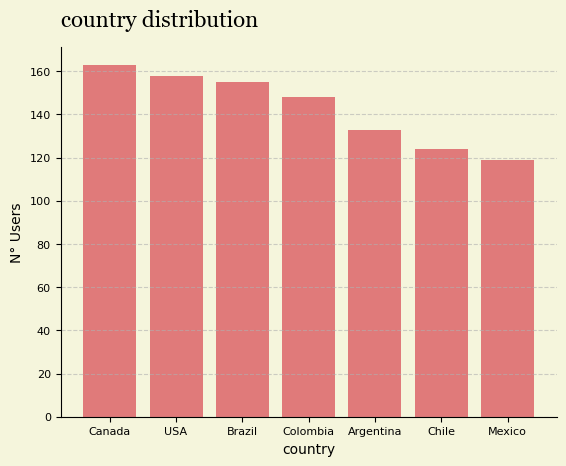

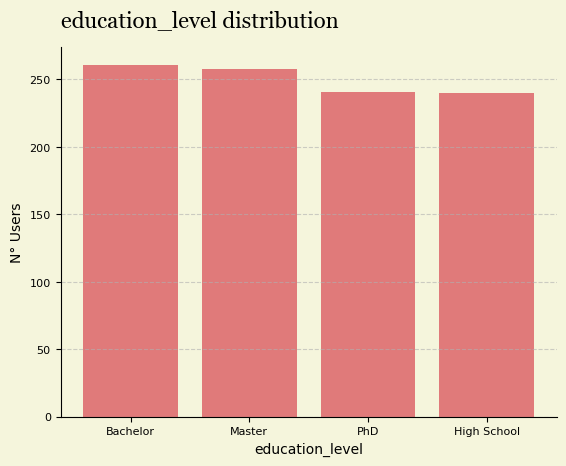

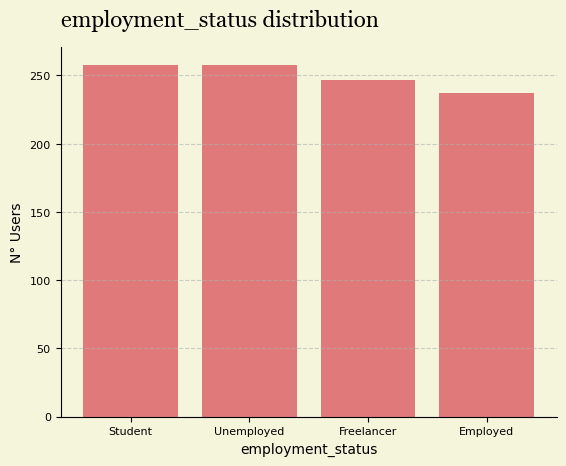

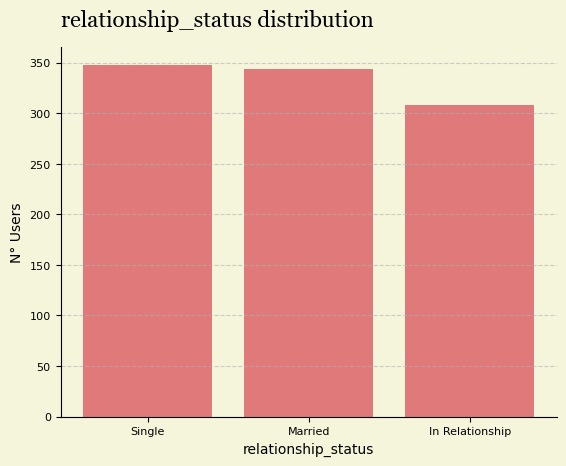

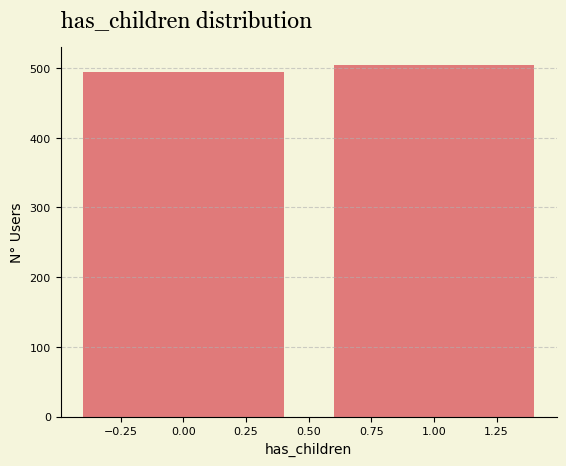

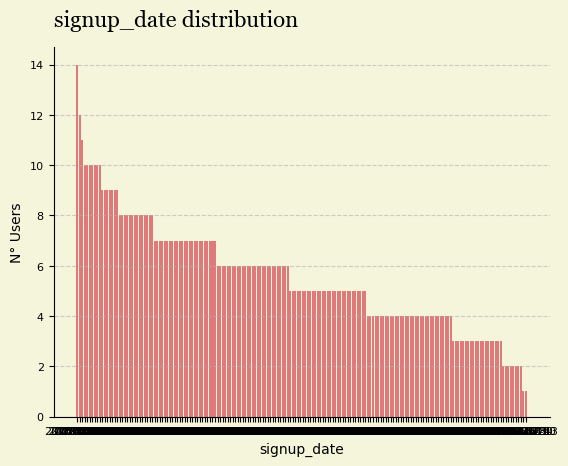

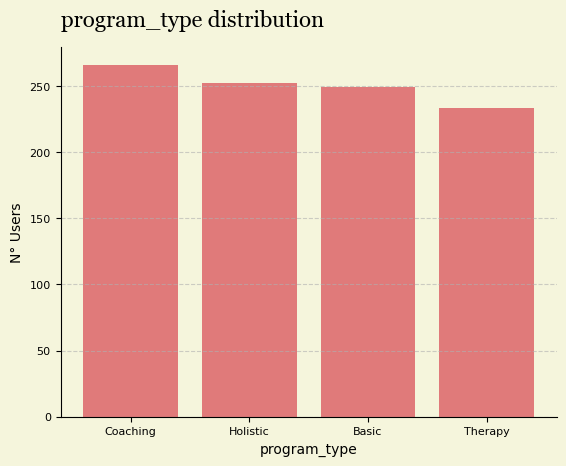

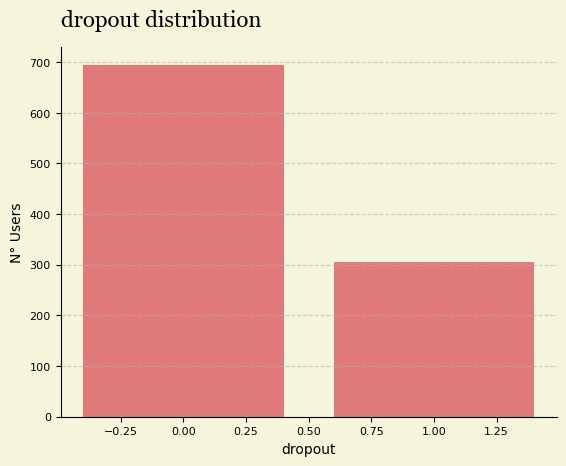

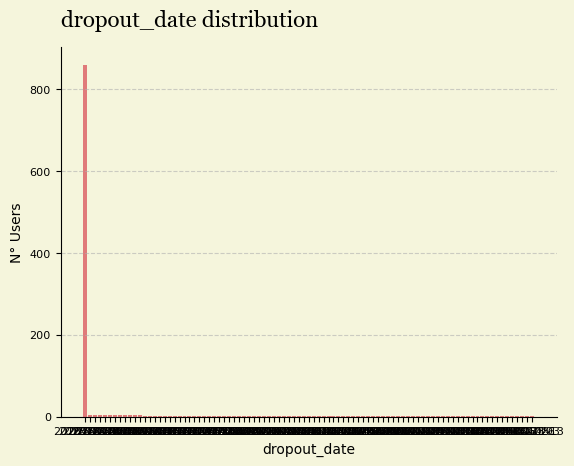

In [108]:
# Dibujando :)
plot_categorical('users.csv')

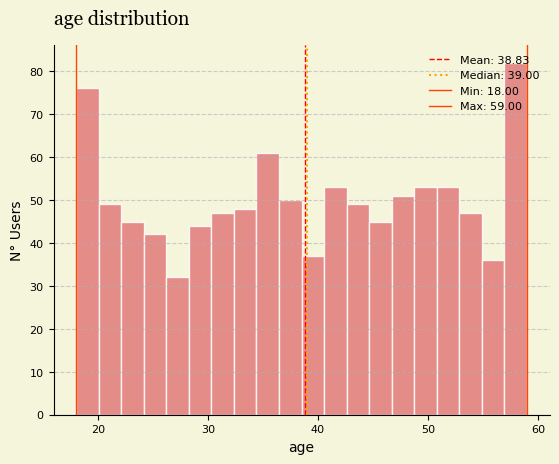

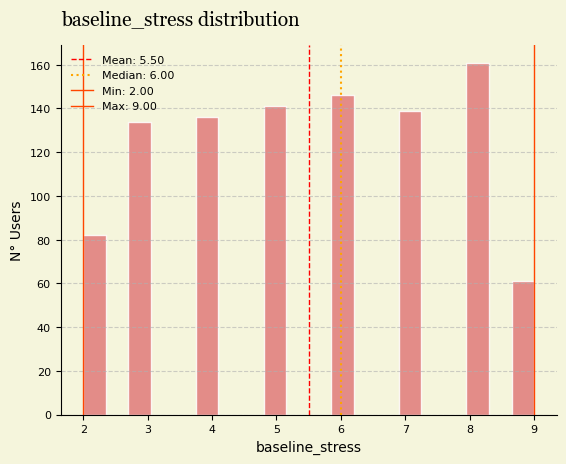

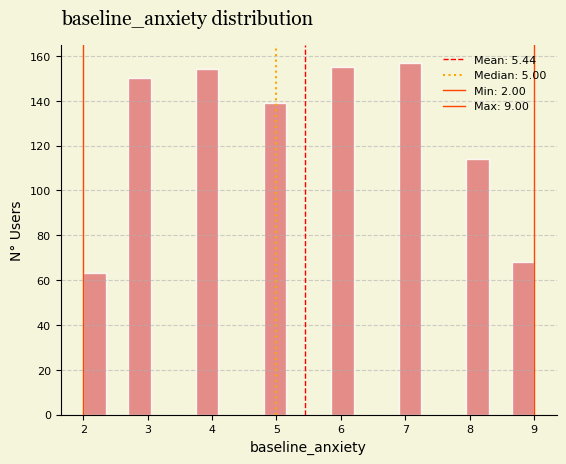

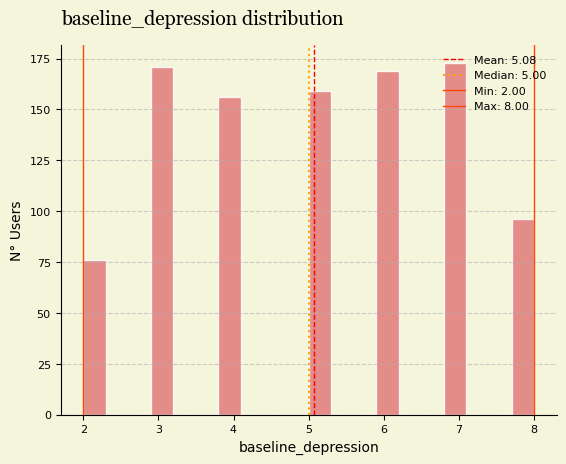

In [136]:
plot_numeric('users.csv')

In [56]:
generate_EDA('assessments.csv')

============== Data frame assessments.csv INSTANT EDA =========================


There are 6454 Observations
There are 8 columns 
there are 7 numeric variables and 1 categorical variables, of the 8 total columns

Numerical Columns:
 + Index(['assessment_id', 'user_id', 'stress_score', 'anxiety_score',
       'depresionscore', 'sleep_quality', 'mood_score'],
      dtype='object')

Categorical Columns: 
 Index(['date'], dtype='object')


============== Numeric variables info =========================

       assessment_id      user_id  stress_score  anxiety_score  \
count    6454.000000  6454.000000   6454.000000    6454.000000   
mean     3227.500000   501.095910      5.977533       5.475984   
std      1863.253651   286.135905      2.362334       2.048300   
min         1.000000     1.000000      2.000000       2.000000   
25%      1614.250000   259.250000      4.000000       4.000000   
50%      3227.500000   502.000000      6.000000       5.000000   
75%      4840.750000   745.00000

,assessment_id,user_id,date,stress_score,anxiety_score,depresionscore,sleep_quality,mood_score
0,1,1,2025-12-10,9.0,9.0,5.0,4.0,7.0
1,2,1,2025-11-25,9.0,7.0,10.0,4.0,5.0
2,3,1,2025-11-02,9.0,5.0,7.0,7.0,4.0
3,4,1,2025-11-27,9.0,8.0,5.0,6.0,9.0
4,5,1,2025-12-06,7.0,6.0,5.0,9.0,6.0


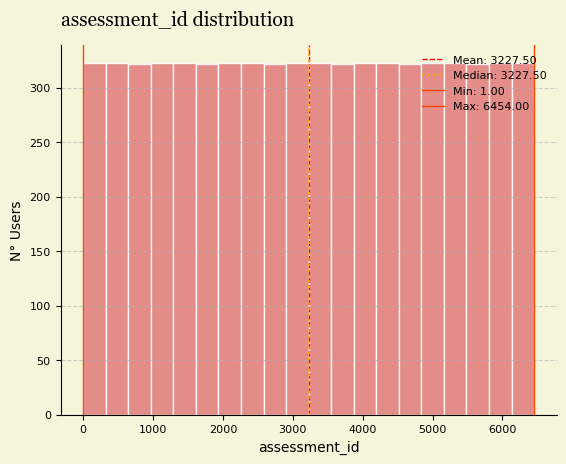

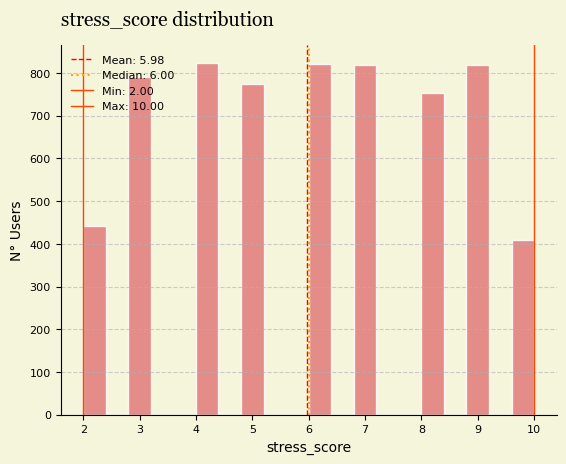

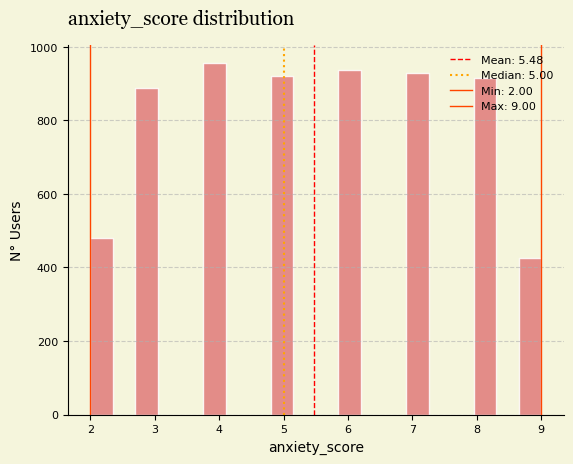

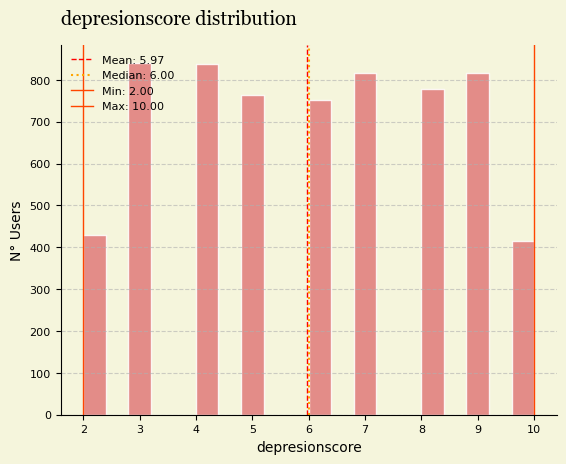

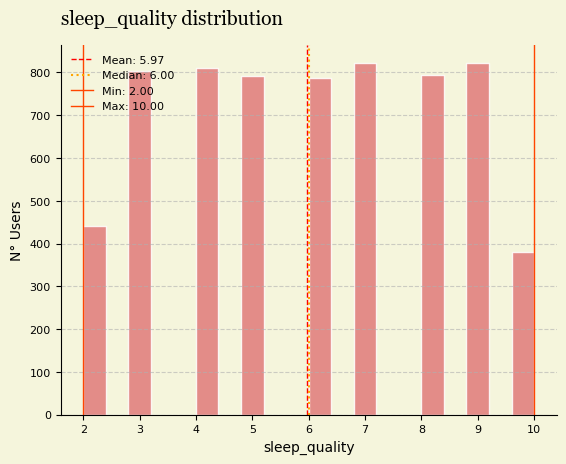

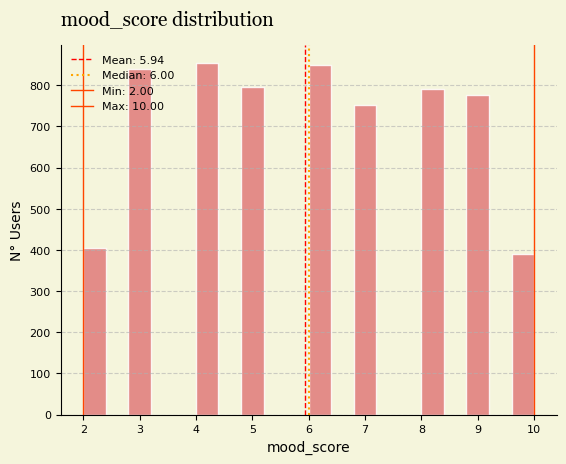

In [138]:
plot_numeric('assessments.csv')

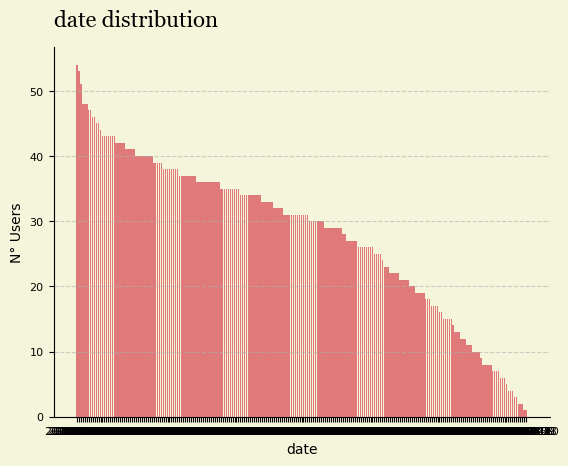

In [140]:
'''As the EDA was sharing:
there was only one categorical variable in this ocasion: DATE.
As the experiment has an start date and a finish date and not every user singed up from the beggening,
I considered it was worth it to see this grafic anyway for it´s beauty.'''
plot_categorical('assessments.csv')

In [58]:
generate_EDA('sessions.csv')

============== Data frame sessions.csv INSTANT EDA =========================


There are 15063 Observations
There are 8 columns 
there are 4 numeric variables and 4 categorical variables, of the 8 total columns

Numerical Columns:
 + Index(['session_id', 'user_id', 'duration_min', 'therapist_id'], dtype='object')

Categorical Columns: 
 Index(['date', 'session_type', 'attended', 'topic'], dtype='object')


============== Numeric variables info =========================

         session_id       user_id  duration_min  therapist_id
count  15063.000000  15063.000000  15063.000000  15063.000000
mean    7532.000000    503.619266     64.988050      4.501361
std     4348.457888    292.026372     18.762325      2.290306
min        1.000000      1.000000     45.000000      1.000000
25%     3766.500000    250.000000     45.000000      3.000000
50%     7532.000000    505.000000     60.000000      4.000000
75%    11297.500000    760.000000     90.000000      6.000000
max    15063.000000   1000.00

,session_id,user_id,date,session_type,duration_min,attended,therapist_id,topic
0,1,1,2025-10-31,Massage,60,False,7,Emotional Situation
1,2,1,2025-11-09,Massage,60,True,7,Other
2,3,1,2025-11-19,Yoga,60,False,6,Mother
3,4,1,2025-12-01,Psicotherapy,90,True,6,Mother
4,5,1,2025-12-12,Yoga,60,True,2,Emotional Situation


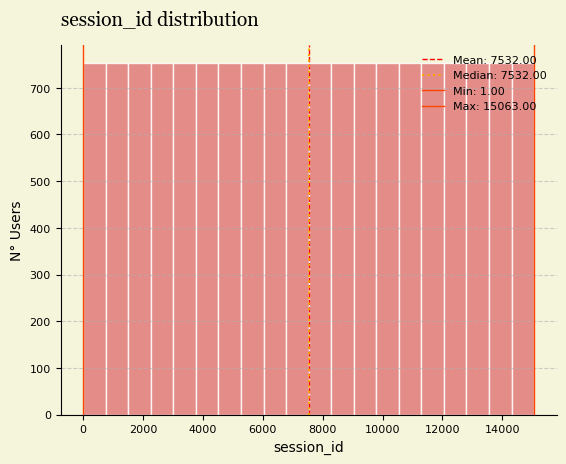

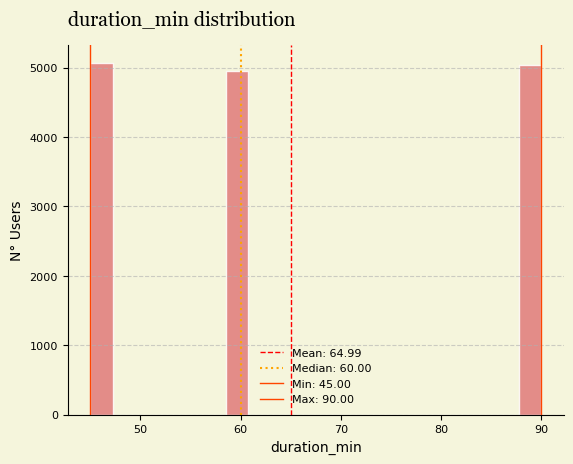

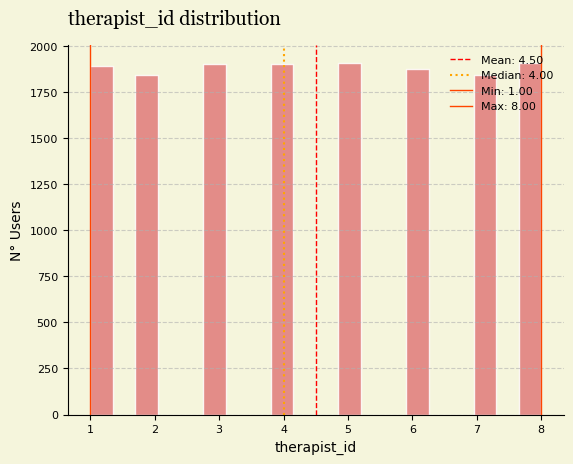

In [142]:
plot_numeric('sessions.csv')

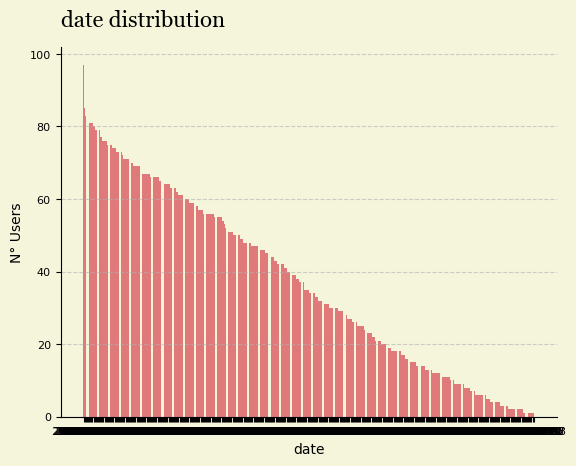

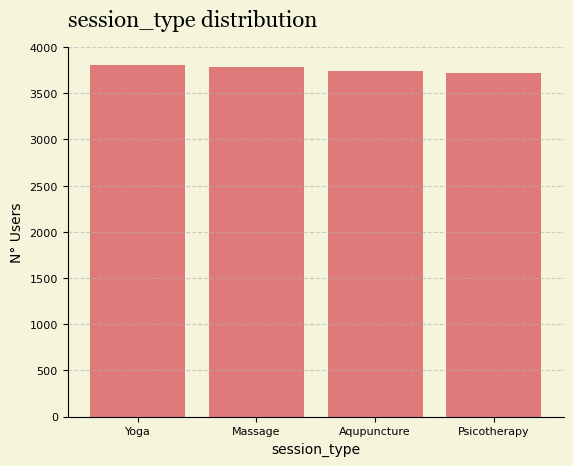

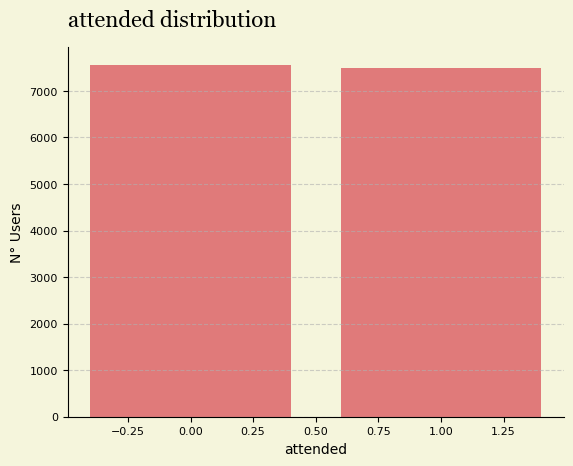

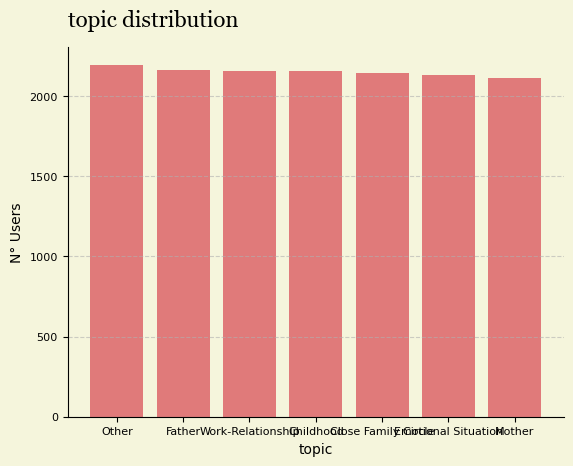

In [144]:
plot_categorical('sessions.csv')

In [60]:
generate_EDA('engagement.csv')

============== Data frame engagement.csv INSTANT EDA =========================


There are 87484 Observations
There are 6 columns 
there are 5 numeric variables and 1 categorical variables, of the 6 total columns

Numerical Columns:
 + Index(['user_id', 'messages_sent', 'exercises_completed',
       'meditations_completed', 'journals_written'],
      dtype='object')

Categorical Columns: 
 Index(['date'], dtype='object')


============== Numeric variables info =========================

            user_id  messages_sent  exercises_completed  \
count  87484.000000   87484.000000         87484.000000   
mean     502.459433       5.998857             1.997702   
std      289.736613       2.821463             0.815590   
min        1.000000       1.000000             1.000000   
25%      259.000000       4.000000             1.000000   
50%      499.000000       6.000000             2.000000   
75%      759.000000       8.000000             3.000000   
max     1000.000000      15.000000  

,user_id,date,messages_sent,exercises_completed,meditations_completed,journals_written
0,1,2025-10-20,9,2,2,2
1,1,2025-10-21,7,3,2,1
2,1,2025-10-22,10,1,2,1
3,1,2025-10-23,11,2,1,2
4,1,2025-10-24,9,2,2,1


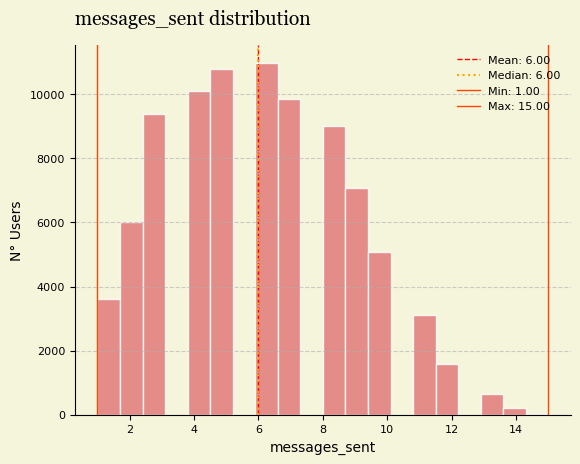

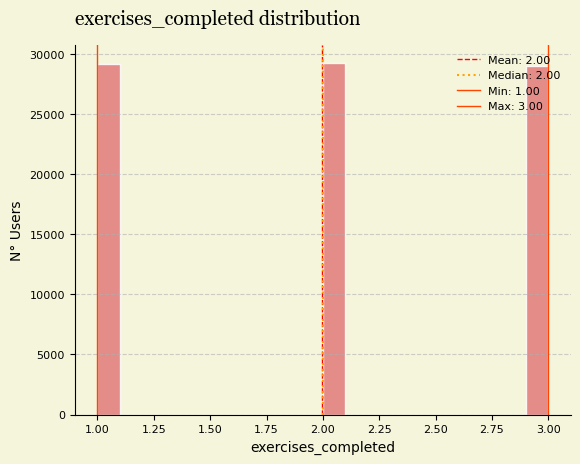

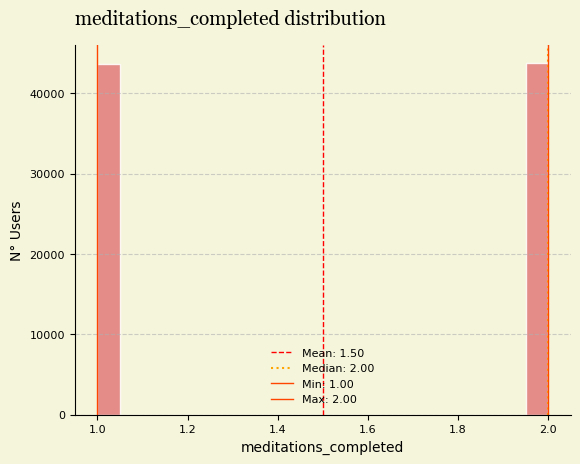

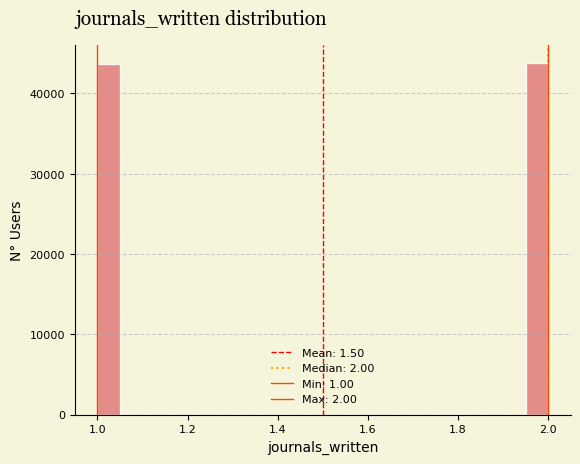

In [146]:
plot_numeric('engagement.csv')

In [62]:
generate_EDA('content_usage.csv')

============== Data frame content_usage.csv INSTANT EDA =========================


There are 87484 Observations
There are 6 columns 
there are 3 numeric variables and 3 categorical variables, of the 6 total columns

Numerical Columns:
 + Index(['user_id', 'content_id', 'minutes_consumed'], dtype='object')

Categorical Columns: 
 Index(['date', 'content_type', 'category'], dtype='object')


============== Numeric variables info =========================

            user_id    content_id  minutes_consumed
count  87484.000000  87484.000000      87484.000000
mean     502.459433  43742.500000         34.390014
std      289.736613  25254.599812         20.350090
min        1.000000      1.000000          5.000000
25%      259.000000  21871.750000         18.000000
50%      499.000000  43742.500000         32.000000
75%      759.000000  65613.250000         46.000000
max     1000.000000  87484.000000         89.000000


============== Categorical variables info =========================

da

,user_id,content_id,date,content_type,category,minutes_consumed
0,1,1,2025-10-20,Reading,Relationships,42
1,1,2,2025-10-21,Video,Relationships,31
2,1,3,2025-10-22,Audio,Relationships,22
3,1,4,2025-10-23,Video,Self-esteem,49
4,1,5,2025-10-24,Audio,Sleep,18


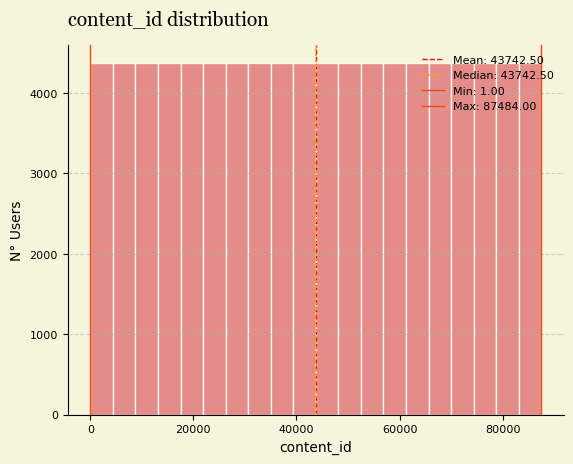

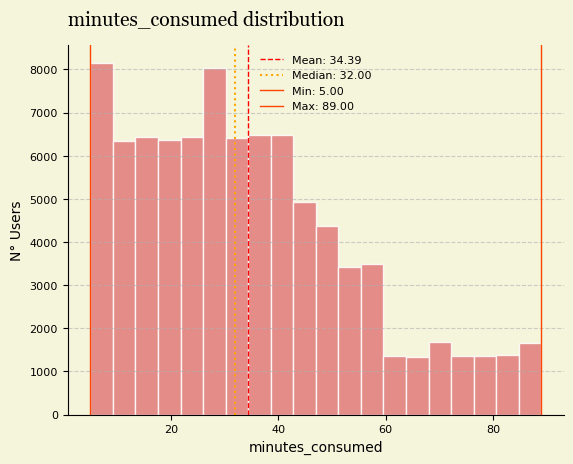

In [150]:
plot_numeric('content_usage.csv')

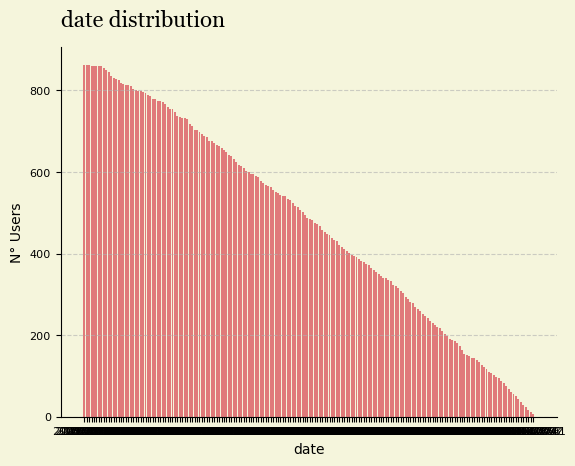

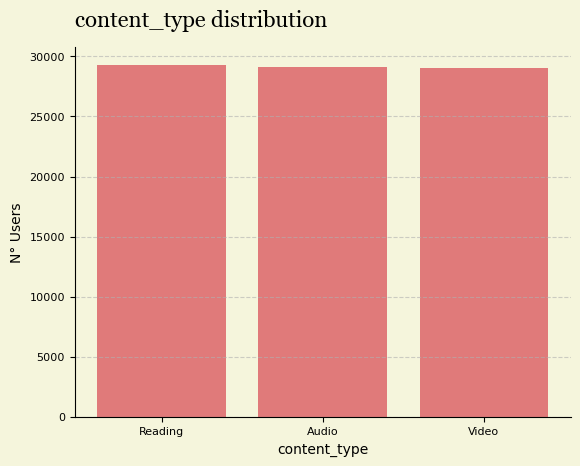

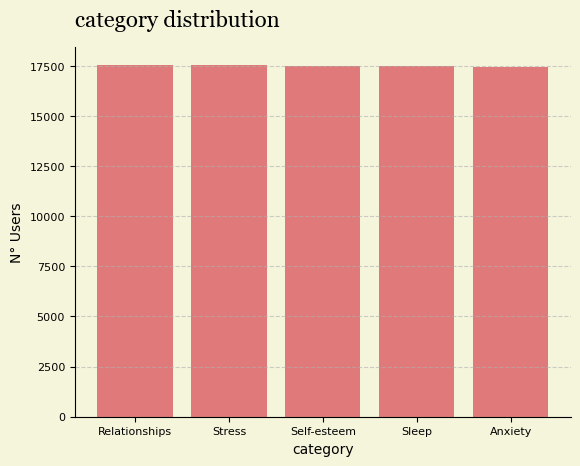

In [154]:
plot_categorical('content_usage.csv')

In [64]:
generate_EDA('outcomes.csv')

============== Data frame outcomes.csv INSTANT EDA =========================


There are 1000 Observations
There are 16 columns 
there are 13 numeric variables and 3 categorical variables, of the 16 total columns

Numerical Columns:
 + Index(['user_id', 'total_active_days', 'total_sessions',
       'total_exercises_completed', 'total_meditations_completed',
       'total_content_consumed_min', 'baseline_stress', 'final_stress',
       'baseline_anxiety', 'final_anxiety', 'baseline_depression',
       'final_depression', 'satisfaction_score'],
      dtype='object')

Categorical Columns: 
 Index(['dropout', 'signup_date', 'dropout_date'], dtype='object')


============== Numeric variables info =========================

           user_id  total_active_days  total_sessions  \
count  1000.000000        1000.000000     1000.000000   
mean    500.500000          87.484000        7.501000   
std     288.819436          49.986001        3.417262   
min       1.000000           5.000000       

,user_id,dropout,total_active_days,total_sessions,total_exercises_completed,total_meditations_completed,total_content_consumed_min,baseline_stress,final_stress,baseline_anxiety,final_anxiety,baseline_depression,final_depression,satisfaction_score,signup_date,dropout_date
0,1,True,73,9.0,143,108,2744,5.0,2.0,5.0,2.000000,6.0,2.520906,10.0,2025-10-20,2025-12-31
1,2,False,86,5.0,162,124,3029,3.0,2.0,7.0,2.260570,4.0,2.000000,10.0,2025-10-07,2025-12-31
2,3,False,72,5.0,139,104,2139,4.0,2.0,5.0,2.143725,4.0,2.270505,10.0,2025-10-21,2025-12-31
3,4,False,104,9.0,203,158,3521,2.0,2.0,6.0,2.000000,5.0,2.000000,10.0,2025-09-19,2025-12-31
4,5,False,179,7.0,360,271,6327,7.0,2.0,6.0,2.000000,6.0,2.000000,10.0,2025-07-06,2025-12-31


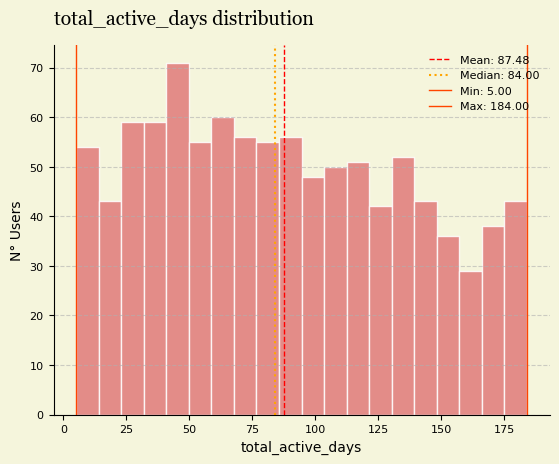

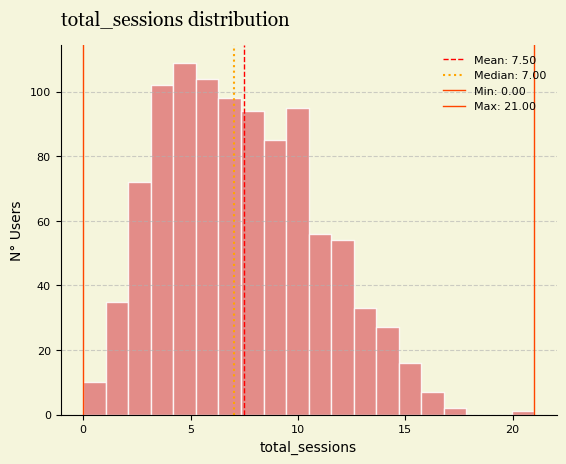

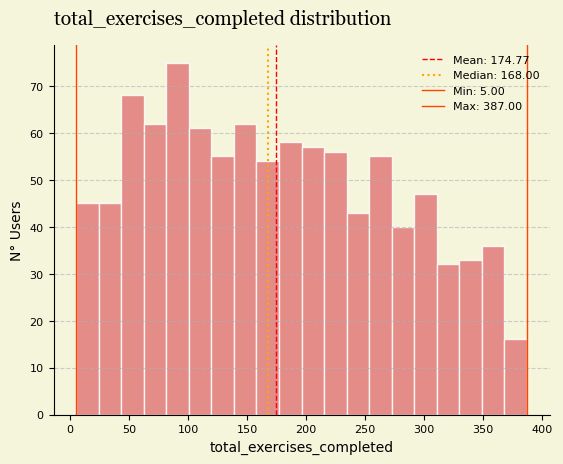

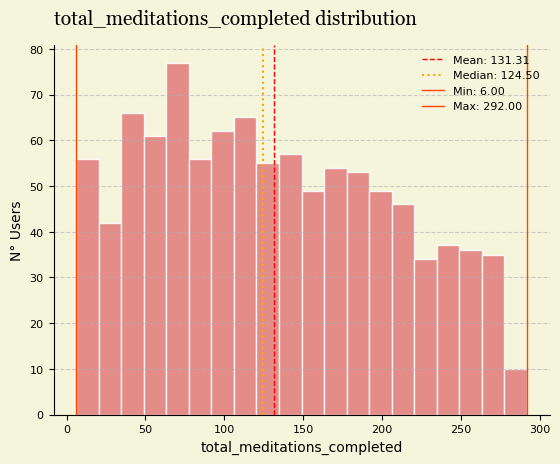

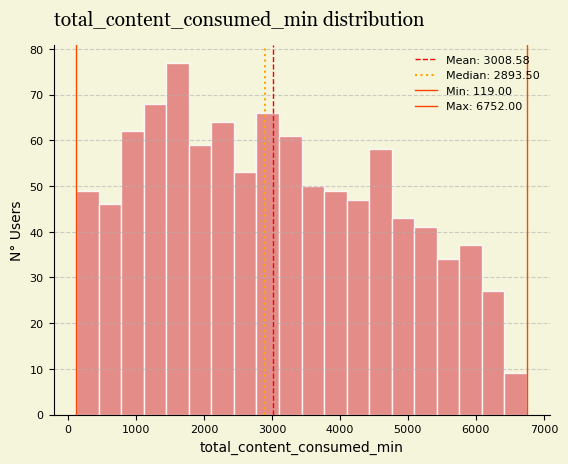

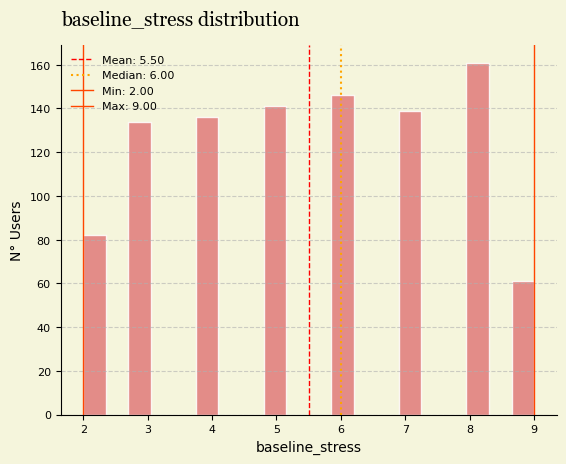

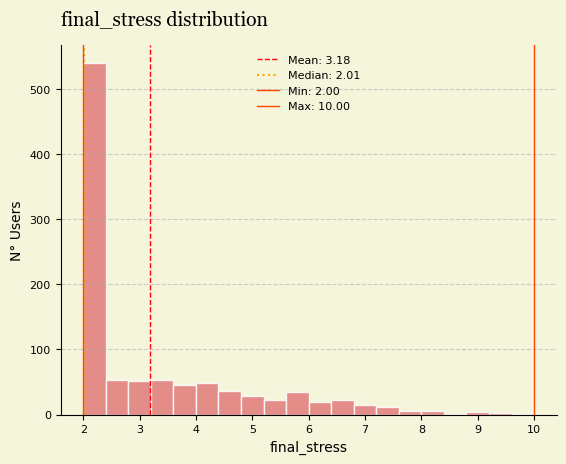

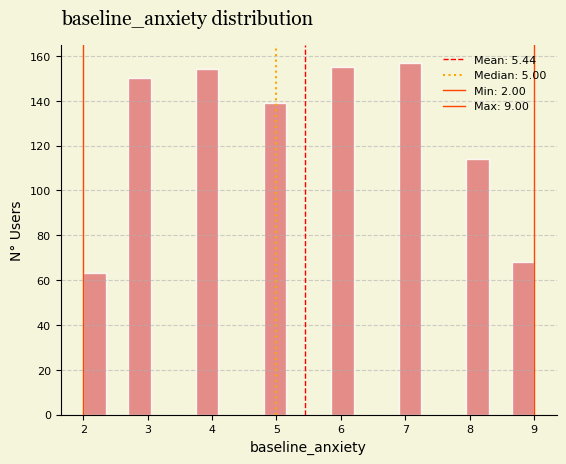

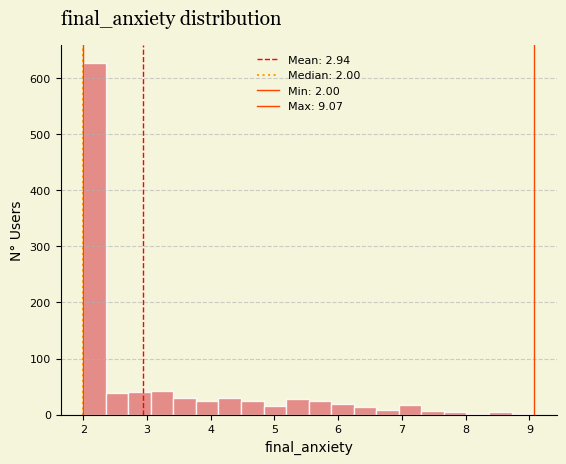

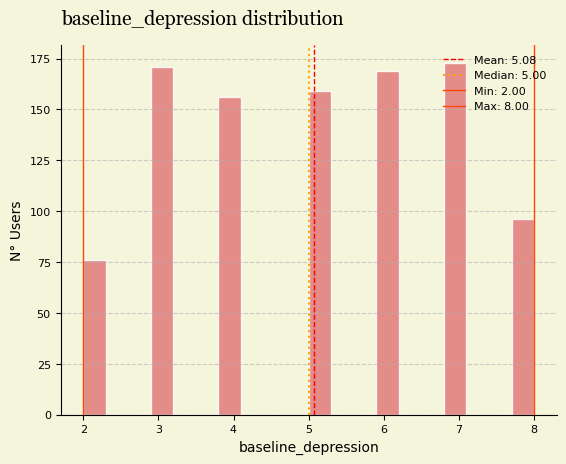

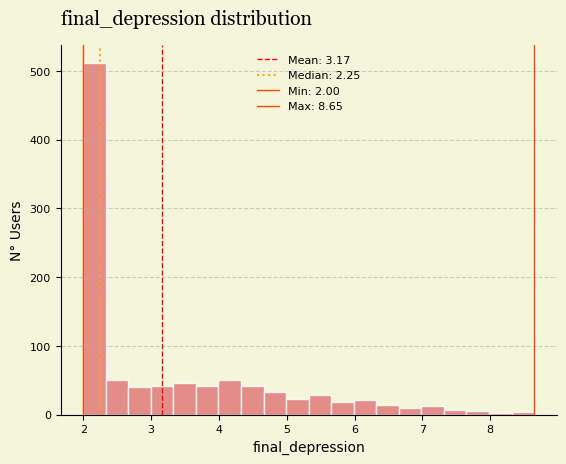

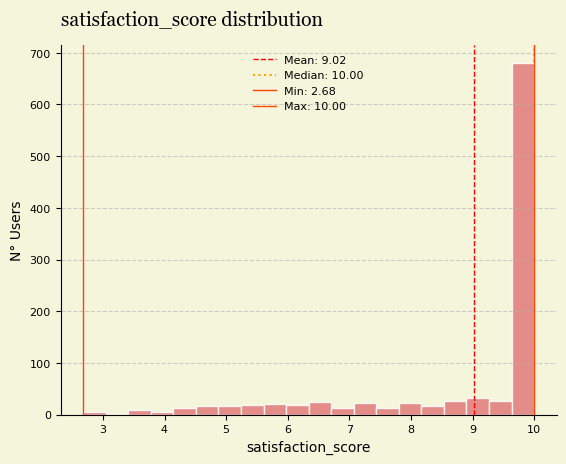

In [156]:
plot_numeric('outcomes.csv')

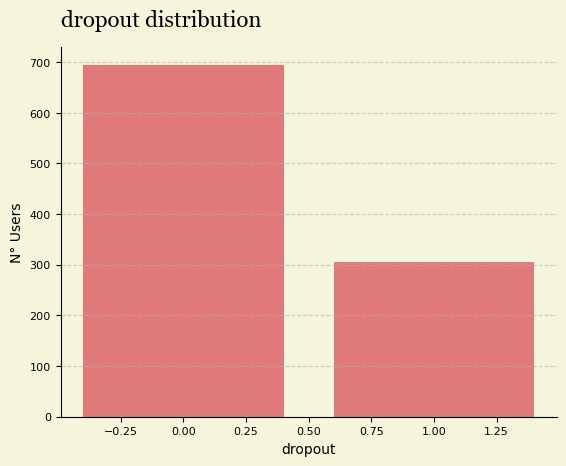

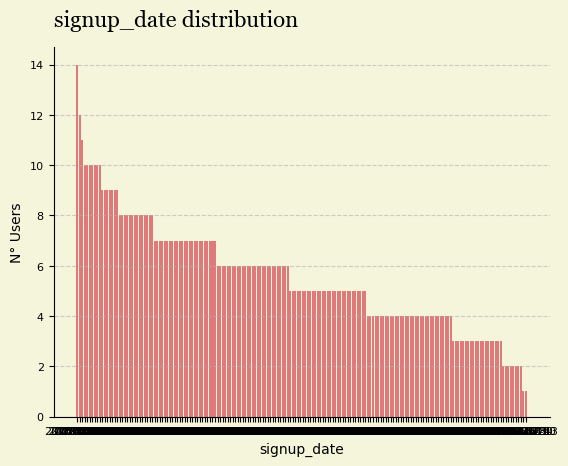

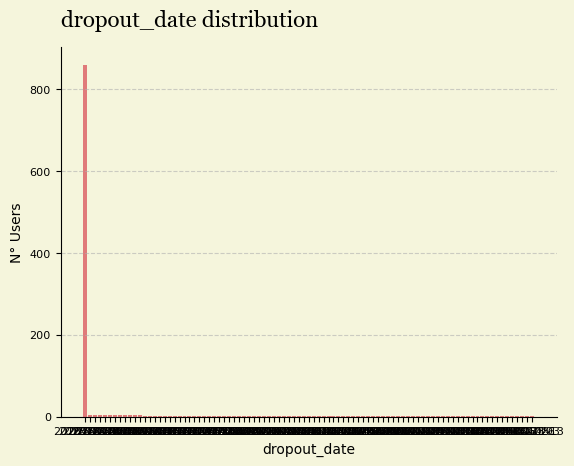

In [160]:
plot_categorical('outcomes.csv')

In [ ]:
"""
With the las dataframe EDA fuctions excecuted,
a basic EDA is finished.

Maybe some graphics are unnecesary like the ID kind of of plots.. 
however the function can always be updated.

Please notice some of this graphics can be convined for a deeper data analyst.
That is for sure to be taken under consideration for each analyser, to go out of the function and to explore.
Namaste.
"""